# F1 Lap Time Optimizer — Exploratory Data Analysis
**Dataset:** 2026 Season, Rounds 1–7 (+ Sprint Qualifying), Top 10 drivers per session  
**Goal:** Understand the data before building the model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('../data/processed/2026_qualifying_training.csv')
print(f'Total laps: {len(df)}')
print(f'Drivers: {sorted(df["Driver"].unique())}')
df.head()

Total laps: 576
Drivers: ['ANT', 'BEA', 'BOR', 'COL', 'GAS', 'HAD', 'HAM', 'HUL', 'LAW', 'LEC', 'LIN', 'NOR', 'PIA', 'RUS', 'SAI', 'VER']


,Driver,Team,LapTime,Sector1Time,Sector2Time,Sector3Time,Compound,TyreLife,SpeedI1,SpeedI2,...,Humidity,WindSpeed,Round,SessionType,CircuitType,LapTimeSeconds,S1Seconds,S2Seconds,S3Seconds,TeamTier
0,RUS,Mercedes,0 days 00:01:19.840000,0 days 00:00:27.990000,0 days 00:00:17.599000,0 days 00:00:34.251000,SOFT,2.0,265.0,278.0,...,63.718947,2.354737,1,Q,street,79.840,27.990,17.599,34.251,3.0
1,RUS,Mercedes,0 days 00:01:19.507000,0 days 00:00:27.908000,0 days 00:00:17.413000,0 days 00:00:34.186000,SOFT,7.0,266.0,282.0,...,63.718947,2.354737,1,Q,street,79.507,27.908,17.413,34.186,3.0
2,RUS,Mercedes,0 days 00:01:18.934000,0 days 00:00:27.816000,0 days 00:00:17.287000,0 days 00:00:33.831000,SOFT,2.0,273.0,285.0,...,63.718947,2.354737,1,Q,street,78.934,27.816,17.287,33.831,3.0
3,RUS,Mercedes,0 days 00:01:18.987000,0 days 00:00:27.662000,0 days 00:00:17.426000,0 days 00:00:33.899000,SOFT,5.0,268.0,280.0,...,63.718947,2.354737,1,Q,street,78.987,27.662,17.426,33.899,3.0
4,RUS,Mercedes,0 days 00:01:19.084000,0 days 00:00:27.674000,0 days 00:00:17.488000,0 days 00:00:33.922000,SOFT,3.0,269.0,274.0,...,63.718947,2.354737,1,Q,street,79.084,27.674,17.488,33.922,3.0


## 1. Dataset Overview

In [2]:
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nBasic stats:')
df[['LapTimeSeconds','S1Seconds','S2Seconds','S3Seconds','TyreLife','AirTemp','TrackTemp']].describe()

Driver             object
Team               object
LapTime            object
Sector1Time        object
Sector2Time        object
Sector3Time        object
Compound           object
TyreLife          float64
SpeedI1           float64
SpeedI2           float64
SpeedFL           float64
SpeedST           float64
IsPersonalBest       bool
LapNumber         float64
AirTemp           float64
TrackTemp         float64
Humidity          float64
WindSpeed         float64
Round               int64
SessionType        object
CircuitType        object
LapTimeSeconds    float64
S1Seconds         float64
S2Seconds         float64
S3Seconds         float64
TeamTier          float64
dtype: object

Missing values:
SpeedI1    1
SpeedST    1
dtype: int64

Basic stats:


,LapTimeSeconds,S1Seconds,S2Seconds,S3Seconds,TyreLife,AirTemp,TrackTemp
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,82.830484,25.167648,29.390964,28.271873,3.701389,22.749638,38.014358
std,8.217514,4.509371,6.476832,7.780813,2.249111,5.846215,8.719328
min,72.051000,18.827000,17.284000,17.464000,2.000000,16.401667,28.171667
25%,74.181500,21.019750,23.536000,22.869250,2.000000,17.758228,30.875949
50%,80.469500,24.331500,28.620000,29.069500,3.000000,21.275949,34.272632
75%,90.131500,30.021500,34.168250,34.298750,5.000000,25.402573,43.576505
max,95.160000,33.200000,40.763000,42.134000,15.000000,33.922222,52.272881


In [3]:
# laps per round and session
pivot = df.groupby(['Round','SessionType'])['Driver'].count().rename('Laps').reset_index()
print(pivot.to_string(index=False))

 Round SessionType  Laps
     1           Q    58
     2           Q    60
     2          SQ    51
     3           Q    63
     4           Q    60
     4          SQ    44
     5           Q    70
     5          SQ    55
     6           Q    75
     7           Q    40


## 2. Lap Time Distributions per Round

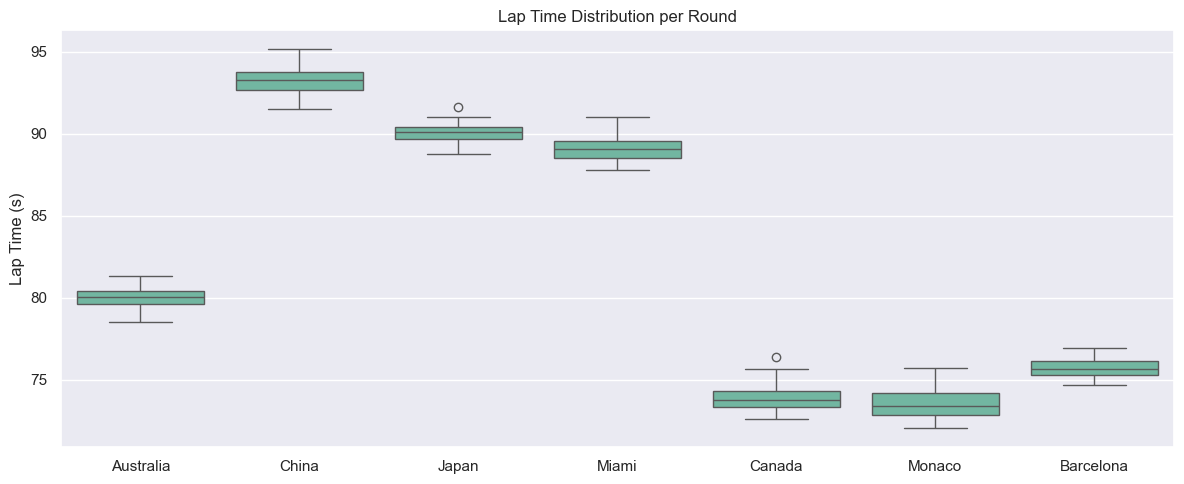

In [4]:
round_labels = {
    1: 'Australia', 2: 'China', 3: 'Japan',
    4: 'Miami', 5: 'Canada', 6: 'Monaco', 7: 'Barcelona'
}
df['RoundName'] = df['Round'].map(round_labels)

fig, ax = plt.subplots()
order = [round_labels[i] for i in sorted(round_labels)]
sns.boxplot(data=df, x='RoundName', y='LapTimeSeconds', order=order, ax=ax)
ax.set_title('Lap Time Distribution per Round')
ax.set_xlabel('')
ax.set_ylabel('Lap Time (s)')
plt.tight_layout()
plt.show()

## 3. Sector Time Distributions

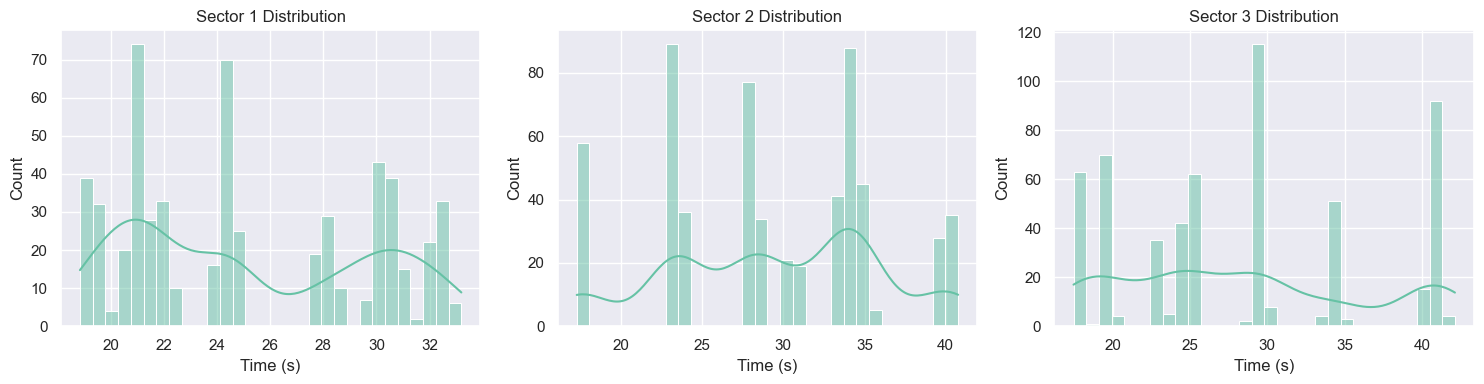

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes, ['S1Seconds','S2Seconds','S3Seconds'], ['Sector 1','Sector 2','Sector 3']):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'{label} Distribution')
    ax.set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## 4. Driver Performance — Fastest Lap per Round

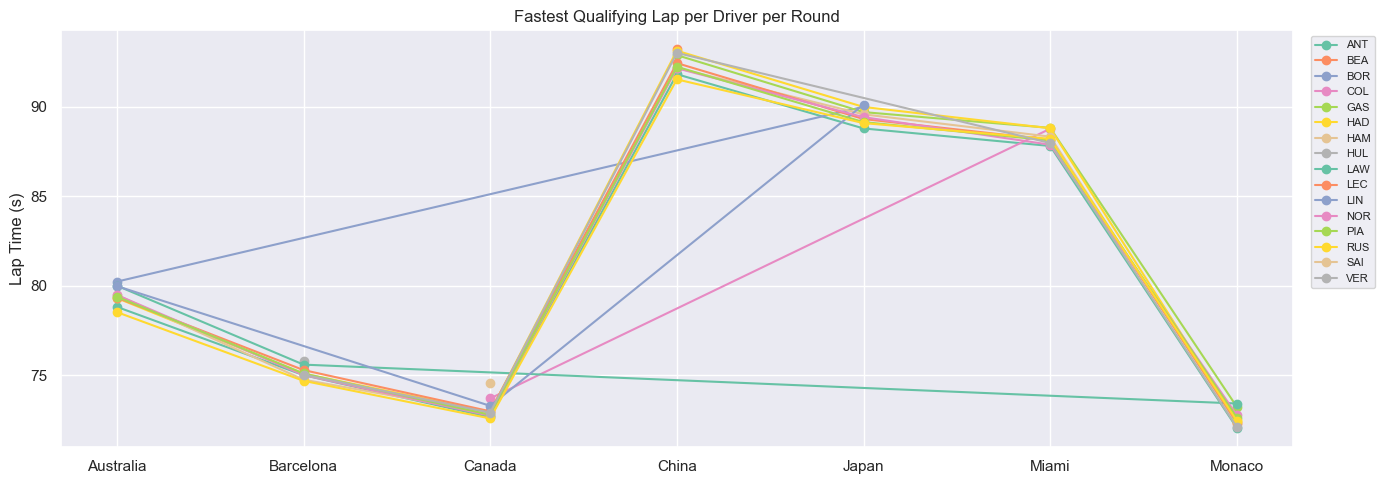

In [6]:
fastest = df.groupby(['Driver','RoundName'])['LapTimeSeconds'].min().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for driver, grp in fastest.groupby('Driver'):
    ax.plot(grp['RoundName'], grp['LapTimeSeconds'], marker='o', label=driver)
ax.set_title('Fastest Qualifying Lap per Driver per Round')
ax.set_xlabel('')
ax.set_ylabel('Lap Time (s)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 5. Verstappen — Sector Times Across Rounds

VER laps in dataset: 45


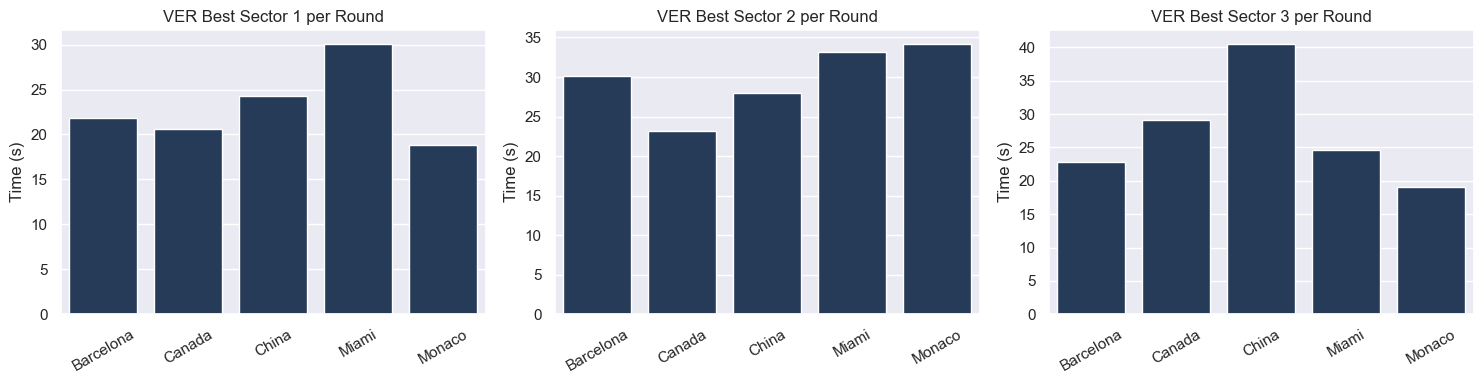

In [7]:
ver = df[df['Driver'] == 'VER'].copy()
print(f'VER laps in dataset: {len(ver)}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes, ['S1Seconds','S2Seconds','S3Seconds'], ['Sector 1','Sector 2','Sector 3']):
    ver_fastest = ver.groupby('RoundName')[col].min().reset_index()
    sns.barplot(data=ver_fastest, x='RoundName', y=col, ax=ax, color='#1E3A5F')
    ax.set_title(f'VER Best {label} per Round')
    ax.set_xlabel('')
    ax.set_ylabel('Time (s)')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 6. Correlation — What Drives Lap Time?

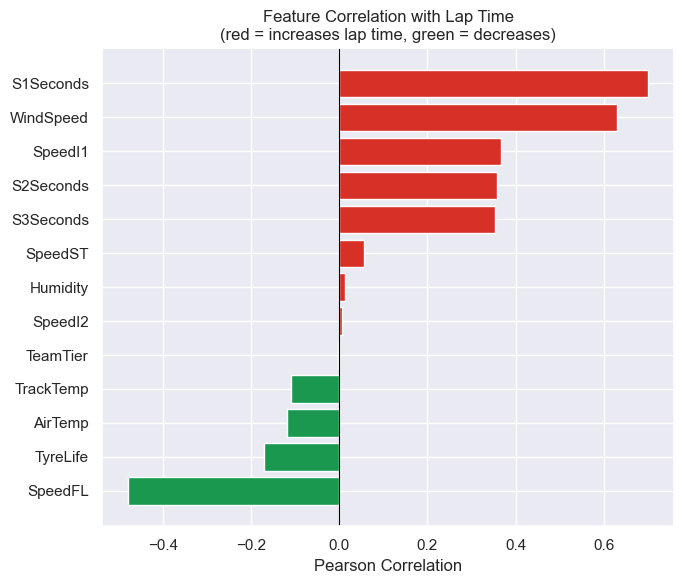

           LapTimeSeconds
SpeedFL         -0.478942
TyreLife        -0.170153
AirTemp         -0.117922
TrackTemp       -0.108292
TeamTier        -0.002404
SpeedI2          0.006852
Humidity         0.013438
SpeedST          0.056017
S3Seconds        0.352173
S2Seconds        0.358164
SpeedI1          0.366121
WindSpeed        0.629530
S1Seconds        0.700221


In [8]:
features = ['S1Seconds','S2Seconds','S3Seconds','TyreLife','TeamTier',
            'AirTemp','TrackTemp','Humidity','WindSpeed','SpeedI1','SpeedI2','SpeedFL','SpeedST']

corr = df[features + ['LapTimeSeconds']].corr()[['LapTimeSeconds']].drop('LapTimeSeconds')
corr = corr.sort_values('LapTimeSeconds')

fig, ax = plt.subplots(figsize=(7, 6))
colors = ['#d73027' if v > 0 else '#1a9850' for v in corr['LapTimeSeconds']]
ax.barh(corr.index, corr['LapTimeSeconds'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Lap Time\n(red = increases lap time, green = decreases)')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print(corr)

## 7. Tyre Life vs Lap Time

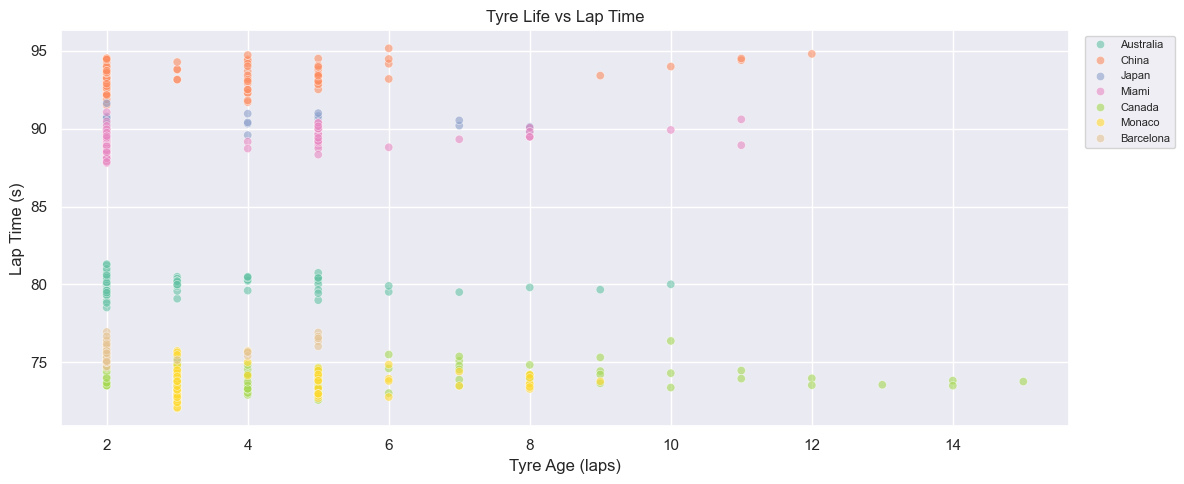

In [9]:
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='TyreLife', y='LapTimeSeconds', hue='RoundName', alpha=0.6, ax=ax)
ax.set_title('Tyre Life vs Lap Time')
ax.set_xlabel('Tyre Age (laps)')
ax.set_ylabel('Lap Time (s)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 8. Q vs SQ — Are Sprint Qualifying Laps Comparable?

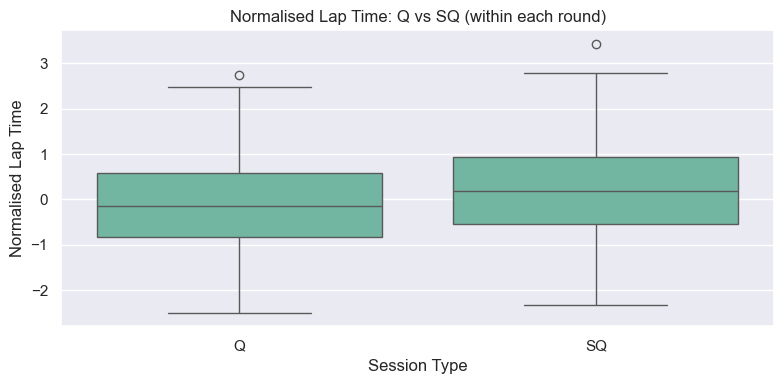

In [10]:
# normalise lap times within each round to compare Q vs SQ fairly
df['LapTimeNorm'] = df.groupby('Round')['LapTimeSeconds'].transform(lambda x: (x - x.mean()) / x.std())

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x='SessionType', y='LapTimeNorm', ax=ax)
ax.set_title('Normalised Lap Time: Q vs SQ (within each round)')
ax.set_ylabel('Normalised Lap Time')
ax.set_xlabel('Session Type')
plt.tight_layout()
plt.show()

## 9. Team Performance Overview

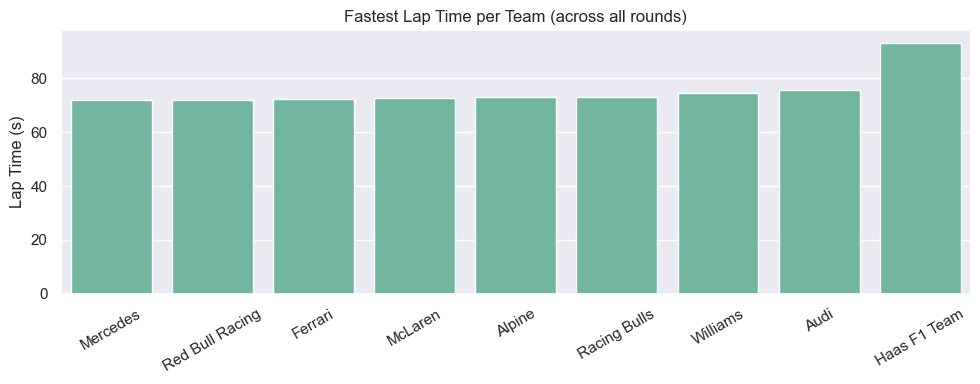

In [11]:
team_fastest = df.groupby('Team')['LapTimeSeconds'].min().sort_values().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=team_fastest, x='Team', y='LapTimeSeconds', ax=ax)
ax.set_title('Fastest Lap Time per Team (across all rounds)')
ax.set_ylabel('Lap Time (s)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()